# 09. Sensitivity Analysis for Unobserved Confounding

The previous notebooks built increasingly sophisticated adjustment designs: regression adjustment, propensity scores, matching, weighting, balance diagnostics, overlap, doubly robust estimation, and TMLE.

This notebook asks the question that remains after all of that:

> What if an important confounder was not measured?

Sensitivity analysis is not a magic test for unobserved confounding. It cannot prove that the hidden variable does or does not exist. What it can do is make the conversation quantitative:

- How large would hidden bias need to be to overturn the conclusion?
- Is that magnitude plausible relative to observed covariates we understand well?
- Would the business decision change under reasonable departures from no unmeasured confounding?

That is a mature way to present observational evidence. It does not pretend the hardest assumption is testable. It asks how fragile the result is to violations of that assumption.

## Learning Goals

By the end of this notebook, you should be able to:

1. Explain why unobserved confounding is not solved by balance on observed covariates.
2. Use an oracle simulation to show how a hidden confounder can bias an adjusted estimate.
3. Compute partial-$R^2$ sensitivity bounds for an omitted confounder in a linear regression.
4. Benchmark hypothetical hidden confounders against observed covariates.
5. Build a tipping-point grid for a simple binary hidden-confounder story.
6. Compute and interpret E-values for a risk-ratio style binary outcome analysis.
7. Implement a simple Rosenbaum-style matched-pair hidden-bias analysis.
8. Write an industry-facing sensitivity readout that is cautious, useful, and decision-oriented.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.special import expit
from scipy.stats import binom
from sklearn.neighbors import NearestNeighbors
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.2")
    dot.attr("graph", labelloc="t", fontsize="18", fontname="DejaVu Sans")
    if title:
        dot.attr(label=title)
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="DejaVu Sans",
        fontsize="11",
        margin="0.12,0.08",
        color="#334155",
    )
    dot.attr("edge", color="#475569", arrowsize="0.8", fontname="DejaVu Sans", fontsize="10")
    for node in sorted(set([u for u, _ in edges] + [v for _, v in edges])):
        dot.node(node, fillcolor=node_colors.get(node, "#f8fafc"))
    for u, v in edges:
        dot.edge(u, v)
    return dot


def partial_r2_from_nested_models(full_model, reduced_model):
    """
    Compute the partial R-squared added by variables in a full model over a reduced model.
    
    Idea:
        Partial R-squared quantifies how strongly a benchmark covariate explains treatment or outcome beyond the existing adjustment set.
    
    Args:
        full_model: Regression model containing the benchmark variable or larger adjustment set.
        reduced_model: Nested regression model without the benchmark variable being assessed.
    
    Returns:
        float: Incremental partial R-squared from the nested model comparison.
    """
    value = (full_model.rsquared - reduced_model.rsquared) / (1 - reduced_model.rsquared)
    return max(0.0, float(value))


def omitted_variable_bias_bound(estimate, se, df_resid, r2_treatment, r2_outcome):
    """
    Compute a Cinelli-Hazlett style omitted-variable bias bound for a linear treatment coefficient.
    
    Idea:
        The bound shows how much an unobserved confounder with specified explanatory strength could move the estimated coefficient.
    
    Args:
        estimate: Observed treatment coefficient or effect estimate being stress-tested.
        se: Standard error of the observed treatment estimate.
        df_resid: Residual degrees of freedom from the fitted linear model.
        r2_treatment: Partial R-squared linking the hypothetical confounder to treatment.
        r2_outcome: Partial R-squared linking the hypothetical confounder to outcome.
    
    Returns:
        float: Absolute bias bound on the treatment coefficient.
    """
    r2_treatment = np.asarray(r2_treatment, dtype=float)
    r2_outcome = np.asarray(r2_outcome, dtype=float)
    r2_treatment = np.clip(r2_treatment, 0, 0.999)
    r2_outcome = np.clip(r2_outcome, 0, 0.999)
    return se * np.sqrt(df_resid * r2_treatment * r2_outcome / ((1 - r2_treatment) * (1 - r2_outcome)))


def robustness_value_for_null(estimate, se, df_resid):
    """
    Find the equal-strength confounder needed to move a coefficient estimate to zero.
    
    Idea:
        This summarizes sensitivity by asking how strongly an omitted variable would need to relate to treatment and outcome to erase the result.
    
    Args:
        estimate: Observed treatment coefficient or effect estimate being stress-tested.
        se: Standard error of the observed treatment estimate.
        df_resid: Residual degrees of freedom from the fitted linear model.
    
    Returns:
        float: Partial R-squared strength required for a null-shifting confounder.
    """
    t_value = abs(estimate / se)
    return t_value / (np.sqrt(df_resid) + t_value)


def e_value(rr):
    """
    Compute the E-value for a risk ratio on the harmful-effect scale.
    
    Idea:
        The E-value expresses how strong unmeasured confounding would need to be, on the risk-ratio scale, to explain away the observed association.
    
    Args:
        rr: Risk ratio placed on the harmful-effect scale for the E-value calculation.
    
    Returns:
        float: E-value corresponding to the supplied risk ratio.
    """
    rr = float(rr)
    if rr <= 0:
        return np.nan
    rr_for_calc = rr if rr >= 1 else 1 / rr
    return rr_for_calc + np.sqrt(rr_for_calc * (rr_for_calc - 1))


def effective_sample_size(weights):
    """Compute Kish effective sample size from a vector of weights.

    Args:
        weights: Observation weights used to define the target pseudo-population or summary.

    Returns:
        float: Effective sample size implied by the design or weights.
    """
    weights = np.asarray(weights, dtype=float)
    return (weights.sum() ** 2) / np.sum(weights ** 2)

## 1. Why Sensitivity Analysis Belongs at the End of Observational Adjustment

Observed covariate balance is necessary, but it is not sufficient. We can only check balance for variables we measured. If an unmeasured variable affects both treatment assignment and the outcome, the adjusted comparison may still be biased.

In notation, the standard point-treatment identification condition is often written as:

$$
\{Y(1), Y(0)\} \perp A \mid X.
$$

Sensitivity analysis asks what happens if the real condition would have required an unobserved variable $U$:

$$
\{Y(1), Y(0)\} \perp A \mid X, U.
$$

Rosenbaum and Rubin (1983) framed this as sensitivity to an unobserved covariate. Rosenbaum (1987) developed hidden-bias sensitivity analysis for matched observational studies. More recent work such as VanderWeele and Ding (2017), Cinelli and Hazlett (2019), and Oster (2017) gives applied researchers interpretable ways to quantify how strong unmeasured confounding would need to be.

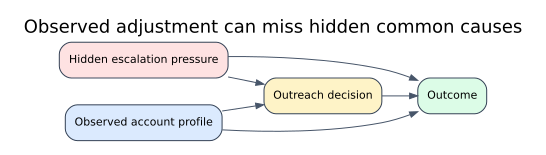

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
hidden_edges = [
    ("Observed account profile", "Outreach decision"),
    ("Observed account profile", "Outcome"),
    ("Hidden escalation pressure", "Outreach decision"),
    ("Hidden escalation pressure", "Outcome"),
    ("Outreach decision", "Outcome"),
]

make_dag(
    hidden_edges,
    title="Observed adjustment can miss hidden common causes",
    node_colors={
        "Observed account profile": "#dbeafe",
        "Hidden escalation pressure": "#fee2e2",
        "Outreach decision": "#fef3c7",
        "Outcome": "#dcfce7",
    },
)

This is the hardest DAG in observational work. The hidden variable is not in the data, so no amount of balance checking can directly verify it.

The point of sensitivity analysis is to replace vague worry with structured questions. A stakeholder may not know whether a hidden factor exists, but they may be able to judge whether it is plausible that such a factor is stronger than the strongest measured risk score or segment variable.

## 2. Running Example: Executive Escalation Pressure

We simulate a SaaS customer-success setting. The treatment is proactive renewal outreach. The continuous outcome is renewal value. We also simulate a binary retention outcome for the E-value section.

The observed data include account segment, tenure, usage, contract value, churn risk, and support capacity. The hidden confounder is **executive escalation pressure**: some accounts receive behind-the-scenes leadership attention because they are politically important, strategically sensitive, or already visible to executives.

This hidden factor affects both treatment and outcome:

- Accounts under escalation pressure are more likely to receive outreach.
- Those accounts also have higher renewal value because leadership attention unlocks concessions, prioritization, or relationship capital.

The analyst does not observe this variable. In the simulation, we keep it so we can compare the real answer with what the analyst would see.

**Dataset and experiment setup.** The sensitivity-analysis dataset represents a business process where some accounts are escalated for executive attention. Escalation is not random. Accounts may be escalated because they are strategically important, visibly distressed, or politically salient. Some of those drivers are observed and some are hidden. The simulation includes an unobserved confounder so the notebook can compare what an analyst sees with what an oracle would know. That makes the sensitivity analysis concrete: it asks how strong an omitted variable would need to be to overturn the observed conclusion.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_hidden_confounding(n=7000, seed=9090):
    """Generate an observational dataset with an explicit hidden confounder.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(["startup", "growth", "enterprise"], p=[0.42, 0.38, 0.20], size=n)
    segment_score = pd.Series(segment).map({"startup": 0.0, "growth": 1.0, "enterprise": 2.0}).to_numpy()

    tenure = np.clip(rng.gamma(shape=2.2, scale=7.5, size=n), 1, 60)
    usage = np.clip(rng.normal(42 + 5 * segment_score + 0.35 * tenure, 13, n), 2, 120)
    contract_value = np.clip(
        rng.lognormal(3.55 + 0.28 * segment_score + 0.005 * usage, 0.55, n),
        20,
        650,
    )
    risk_score = expit(
        1.40
        - 0.050 * usage
        - 0.0045 * contract_value
        + 0.012 * tenure
        - 0.35 * segment_score
        + rng.normal(0, 0.75, n)
    )
    support_capacity = rng.normal(0, 1, n)

    hidden_latent_score = (
        -1.10
        + 0.012 * contract_value
        + 0.85 * (segment == "enterprise")
        + 0.90 * risk_score
        + 0.40 * support_capacity
        + rng.normal(0, 1.0, n)
    )
    executive_pressure = (hidden_latent_score > np.quantile(hidden_latent_score, 0.72)).astype(int)

    treatment_probability = expit(
        -1.10
        + 2.40 * risk_score
        + 0.45 * (segment == "enterprise")
        + 0.25 * (segment == "growth")
        + 0.0040 * contract_value
        - 0.018 * usage
        + 0.65 * support_capacity
        + 1.25 * executive_pressure
    )
    treated = rng.binomial(1, treatment_probability)

    outcome_without_treatment = (
        55
        + 0.16 * usage
        + 0.035 * contract_value
        + 0.10 * tenure
        + 2.60 * segment_score
        - 13.0 * risk_score
        + 4.0 * risk_score**2
        + 5.5 * executive_pressure
        + rng.normal(0, 5.0, n)
    )

    treatment_effect = (
        3.0
        + 0.70 * (segment == "growth")
        + 1.30 * (segment == "enterprise")
        + 0.010 * usage
        - 1.00 * risk_score
        + 0.0008 * contract_value
    )
    outcome = outcome_without_treatment + treatment_effect * treated
    retained = rng.binomial(1, expit(-3.2 + 0.055 * outcome))

    return pd.DataFrame({
        "segment": segment,
        "tenure": tenure,
        "usage": usage,
        "contract_value": contract_value,
        "risk_score": risk_score,
        "support_capacity": support_capacity,
        "executive_pressure": executive_pressure,
        "true_propensity": treatment_probability,
        "treated": treated,
        "outcome": outcome,
        "retained": retained,
        "true_individual_effect": treatment_effect,
    })


df = simulate_hidden_confounding()
true_ate = df["true_individual_effect"].mean()
naive_effect = df.loc[df["treated"] == 1, "outcome"].mean() - df.loc[df["treated"] == 0, "outcome"].mean()

summary = pd.DataFrame({
    "quantity": [
        "Number of accounts",
        "Share receiving outreach",
        "Share with hidden executive pressure",
        "True ATE in simulation",
        "Naive treated-control difference",
        "Naive bias vs true ATE",
    ],
    "value": [
        len(df),
        df["treated"].mean(),
        df["executive_pressure"].mean(),
        true_ate,
        naive_effect,
        naive_effect - true_ate,
    ],
})

smart_display(summary)
smart_display(df.head())

,quantity,value
0,Number of accounts,7000.000
1,Share receiving outreach,0.364
2,Share with hidden executive pressure,0.280
3,True ATE in simulation,3.857
4,Naive treated-control difference,5.073
5,Naive bias vs true ATE,1.215


,segment,tenure,usage,contract_value,risk_score,support_capacity,executive_pressure,true_propensity,treated,outcome,retained,true_individual_effect
0,growth,20.391,48.878,122.197,0.088,-1.222,0,0.139,0,75.907,1,4.198
1,startup,30.361,54.528,43.413,0.305,1.545,0,0.457,0,65.637,1,3.275
2,startup,43.766,42.778,33.166,0.562,-0.019,0,0.401,1,61.371,0,2.892
3,startup,26.375,42.756,20.669,0.265,0.264,0,0.273,0,65.738,1,3.179
4,growth,22.313,44.067,40.434,0.114,0.129,0,0.245,1,71.943,0,4.059


The true effect is known only because this is a simulation. The naive comparison is larger because treated accounts are more likely to have hidden executive pressure.

A real analyst would not observe `executive_pressure`. We will first show what an oracle would reveal, then pretend we do not have it and run sensitivity analyses.

## 3. Analyst Model Versus Oracle Model

The analyst adjusts for observed covariates. The oracle adjusts for the hidden confounder as well.

This comparison is not available in real data, but it teaches us what sensitivity analysis is trying to approximate.

In [5]:
# Fit the statistical model and collect estimates used in the following interpretation.
observed_covariates_formula = "risk_score + usage + contract_value + tenure + support_capacity + C(segment)"

naive_model = smf.ols("outcome ~ treated", data=df).fit()
analyst_model = smf.ols(f"outcome ~ treated + {observed_covariates_formula}", data=df).fit()
oracle_model = smf.ols(f"outcome ~ treated + {observed_covariates_formula} + executive_pressure", data=df).fit()

model_comparison = pd.DataFrame([
    {
        "model": "Naive difference as regression",
        "treatment_estimate": naive_model.params["treated"],
        "std_error": naive_model.bse["treated"],
        "r_squared": naive_model.rsquared,
        "bias_vs_true_ate": naive_model.params["treated"] - true_ate,
    },
    {
        "model": "Observed-covariate adjustment",
        "treatment_estimate": analyst_model.params["treated"],
        "std_error": analyst_model.bse["treated"],
        "r_squared": analyst_model.rsquared,
        "bias_vs_true_ate": analyst_model.params["treated"] - true_ate,
    },
    {
        "model": "Oracle adjustment with hidden confounder",
        "treatment_estimate": oracle_model.params["treated"],
        "std_error": oracle_model.bse["treated"],
        "r_squared": oracle_model.rsquared,
        "bias_vs_true_ate": oracle_model.params["treated"] - true_ate,
    },
])

smart_display(model_comparison)

hidden_distribution = pd.crosstab(
    df["treated"],
    df["executive_pressure"],
    normalize="index",
).rename(index={0: "No outreach", 1: "Outreach"}, columns={0: "No hidden pressure", 1: "Hidden pressure"})

smart_display(hidden_distribution)

,model,treatment_estimate,std_error,r_squared,bias_vs_true_ate
0,Naive difference as regression,5.073,0.215,0.073,1.215
1,Observed-covariate adjustment,5.106,0.147,0.635,1.249
2,Oracle adjustment with hidden confounder,3.919,0.140,0.688,0.062


executive_pressure,No hidden pressure,Hidden pressure
treated,,
No outreach,0.835,0.165
Outreach,0.519,0.481


In Analyst Model Versus Oracle Model, the output is useful only if the comparison has support in the data. Weak overlap shifts the estimate toward extrapolation and away from observed comparisons.

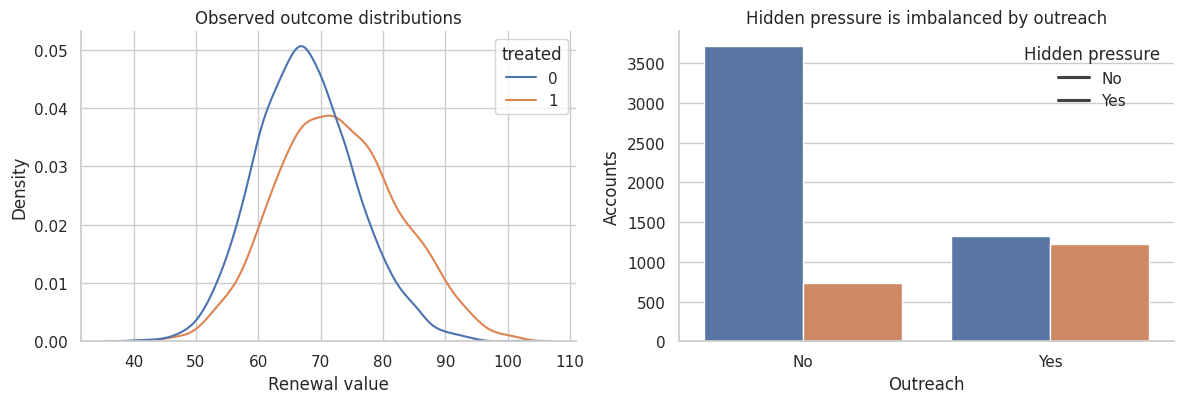

In [6]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.kdeplot(data=df, x="outcome", hue="treated", common_norm=False, fill=False, ax=axes[0])
axes[0].set_title("Observed outcome distributions")
axes[0].set_xlabel("Renewal value")

sns.barplot(
    data=df.groupby(["treated", "executive_pressure"]).size().reset_index(name="n"),
    x="treated",
    y="n",
    hue="executive_pressure",
    ax=axes[1],
)
axes[1].set_title("Hidden pressure is imbalanced by outreach")
axes[1].set_xlabel("Outreach")
axes[1].set_ylabel("Accounts")
axes[1].set_xticklabels(["No", "Yes"])
axes[1].legend(title="Hidden pressure", labels=["No", "Yes"], frameon=False)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The observed-covariate model still overstates the true effect because the hidden confounder is imbalanced and outcome-relevant. The oracle model moves much closer to the true ATE.

In real data, we cannot run the oracle model. Sensitivity analysis asks: how strong would a hidden confounder need to be to produce this kind of movement?

## 4. Partial-$R^2$ Sensitivity Analysis

Cinelli and Hazlett (2019) extend omitted-variable bias logic using interpretable partial-$R^2$ quantities. For a linear regression treatment coefficient, think of two sensitivity parameters:

$$
R^2_{A \sim U \mid X}
$$

measuring how strongly the hidden confounder explains treatment after observed covariates, and

$$
R^2_{Y \sim U \mid A,X}
$$

measuring how strongly the hidden confounder explains the outcome after treatment and observed covariates.

A useful approximate absolute bias bound is:

$$
|Bias| \le SE(\hat\tau)\sqrt{
\frac{df \cdot R^2_{A \sim U \mid X} \cdot R^2_{Y \sim U \mid A,X}}
{(1-R^2_{A \sim U \mid X})(1-R^2_{Y \sim U \mid A,X})}
}.
$$

This lets us ask what combinations of treatment-explanatory strength and outcome-explanatory strength would move the estimate to zero, below a decision threshold, or below a practical-impact threshold.

In [7]:
# Fit the statistical model and collect estimates used in the following interpretation.
analyst_estimate = analyst_model.params["treated"]
analyst_se = analyst_model.bse["treated"]
analyst_df = analyst_model.df_resid
rv_null = robustness_value_for_null(analyst_estimate, analyst_se, analyst_df)

# Oracle-only diagnostic: in real data this row would not be available.
y_full_with_u = oracle_model
y_without_u = analyst_model
a_full_with_u = smf.ols(f"treated ~ {observed_covariates_formula} + executive_pressure", data=df).fit()
a_without_u = smf.ols(f"treated ~ {observed_covariates_formula}", data=df).fit()

true_u_r2_outcome = partial_r2_from_nested_models(y_full_with_u, y_without_u)
true_u_r2_treatment = partial_r2_from_nested_models(a_full_with_u, a_without_u)
true_u_bias_bound = omitted_variable_bias_bound(
    analyst_estimate,
    analyst_se,
    analyst_df,
    true_u_r2_treatment,
    true_u_r2_outcome,
)

sensitivity_summary = pd.DataFrame({
    "quantity": [
        "Observed adjusted estimate",
        "Observed adjusted standard error",
        "Equal-strength robustness value for null",
        "Oracle hidden-confounder partial R2 with treatment",
        "Oracle hidden-confounder partial R2 with outcome",
        "Oracle hidden-confounder bias bound",
        "Actual movement from analyst to oracle estimate",
    ],
    "value": [
        analyst_estimate,
        analyst_se,
        rv_null,
        true_u_r2_treatment,
        true_u_r2_outcome,
        true_u_bias_bound,
        analyst_estimate - oracle_model.params["treated"],
    ],
})

smart_display(sensitivity_summary)

,quantity,value
0,Observed adjusted estimate,5.106
1,Observed adjusted standard error,0.147
2,Equal-strength robustness value for null,0.293
3,Oracle hidden-confounder partial R2 with treat...,0.060
4,Oracle hidden-confounder partial R2 with outcome,0.145
5,Oracle hidden-confounder bias bound,1.284
6,Actual movement from analyst to oracle estimate,1.187


The robustness value is the equal-strength partial-$R^2$ value that would be needed, on both the treatment and outcome sides, to move the estimated coefficient to zero. Larger values mean the point estimate is harder to explain away through a hidden confounder of equal treatment and outcome strength.

Because this is a simulation, we can also compute the hidden confounder's true partial-$R^2$ values. That is not a real-data luxury, but it helps calibrate the sensitivity scale.

## 5. Benchmark Against Observed Covariates

Sensitivity parameters are only useful if stakeholders can reason about them. One practical strategy is benchmarking: compare the hypothetical hidden confounder with observed covariates.

For each observed covariate, we compute how much it explains treatment and outcome after the other observed covariates are already included. This gives a scale for statements like:

> A hidden confounder would need to be roughly as outcome-relevant as contract value and more treatment-relevant than support capacity to overturn the decision.

In [8]:
# Fit the statistical model and collect estimates used in the following interpretation.
benchmark_terms = ["risk_score", "usage", "contract_value", "tenure", "support_capacity", "C(segment)"]
benchmark_labels = {
    "risk_score": "Risk score",
    "usage": "Usage",
    "contract_value": "Contract value",
    "tenure": "Tenure",
    "support_capacity": "Support capacity",
    "C(segment)": "Segment group",
}

benchmark_rows = []
for term in benchmark_terms:
    rest = [x for x in benchmark_terms if x != term]
    rest_formula = " + ".join(rest)
    full_formula = " + ".join(rest + [term])

    y_reduced = smf.ols(f"outcome ~ treated + {rest_formula}", data=df).fit()
    y_full = smf.ols(f"outcome ~ treated + {full_formula}", data=df).fit()
    a_reduced = smf.ols(f"treated ~ {rest_formula}", data=df).fit()
    a_full = smf.ols(f"treated ~ {full_formula}", data=df).fit()

    r2_y = partial_r2_from_nested_models(y_full, y_reduced)
    r2_a = partial_r2_from_nested_models(a_full, a_reduced)
    bias_bound = omitted_variable_bias_bound(analyst_estimate, analyst_se, analyst_df, r2_a, r2_y)

    benchmark_rows.append({
        "covariate": benchmark_labels[term],
        "partial_r2_with_treatment": r2_a,
        "partial_r2_with_outcome": r2_y,
        "implied_bias_bound_if_hidden": bias_bound,
        "estimate_after_subtracting_bound": analyst_estimate - bias_bound,
    })

benchmark_table = pd.DataFrame(benchmark_rows).sort_values("implied_bias_bound_if_hidden", ascending=False)

smart_display(benchmark_table)

,covariate,partial_r2_with_treatment,partial_r2_with_outcome,implied_bias_bound_if_hidden,estimate_after_subtracting_bound
2,Contract value,2.374e-02,0.125,0.726,4.380
5,Segment group,1.551e-02,0.154,0.660,4.446
0,Risk score,2.443e-02,0.048,0.439,4.667
4,Support capacity,8.719e-02,0.006,0.287,4.819
1,Usage,3.704e-03,0.092,0.239,4.867
3,Tenure,2.041e-04,0.040,0.036,5.071


In Benchmark Against Observed Covariates, the output is useful only if the comparison has support in the data. When overlap is thin, the model is doing more of the work than the data.

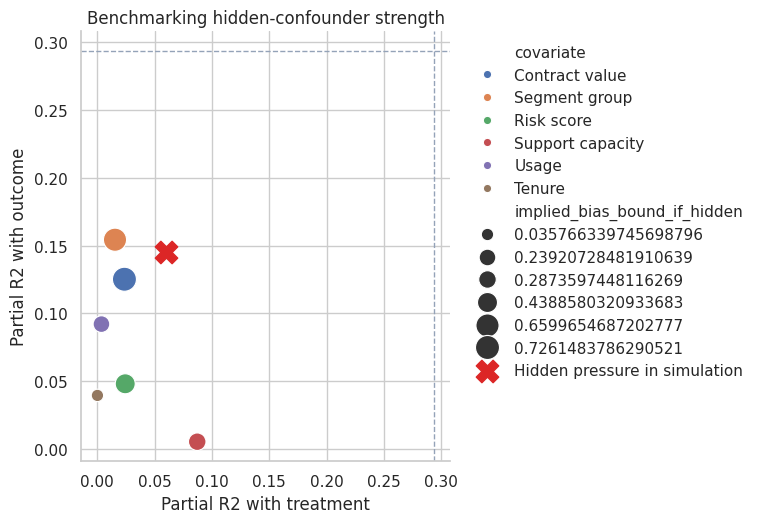

In [9]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(7.8, 5.4))
sns.scatterplot(
    data=benchmark_table,
    x="partial_r2_with_treatment",
    y="partial_r2_with_outcome",
    size="implied_bias_bound_if_hidden",
    hue="covariate",
    sizes=(80, 300),
    ax=ax,
)
ax.scatter(true_u_r2_treatment, true_u_r2_outcome, s=260, marker="X", color="#dc2626", label="Hidden pressure in simulation")
ax.axvline(rv_null, color="#94a3b8", linestyle="--", linewidth=1)
ax.axhline(rv_null, color="#94a3b8", linestyle="--", linewidth=1)
ax.set_title("Benchmarking hidden-confounder strength")
ax.set_xlabel("Partial R2 with treatment")
ax.set_ylabel("Partial R2 with outcome")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The benchmark plot turns abstract sensitivity parameters into domain language. If a hypothetical hidden confounder must be stronger than any observed covariate on both dimensions, the result may be more credible. If a hidden confounder comparable to ordinary observed variables could overturn the result, the finding is fragile.

In this simulation, the hidden executive pressure variable is not science fiction. It is a plausible business process variable. That is exactly the kind of thing sensitivity analysis should surface.

## 6. Sensitivity Contour: How Much Bias Could a Hidden Confounder Produce?

Now vary the two partial-$R^2$ sensitivity parameters over a grid and compute the lower adjusted estimate after subtracting the bias bound.

This plot answers:

> Under each assumed hidden-confounder strength, how much of the adjusted treatment effect remains?

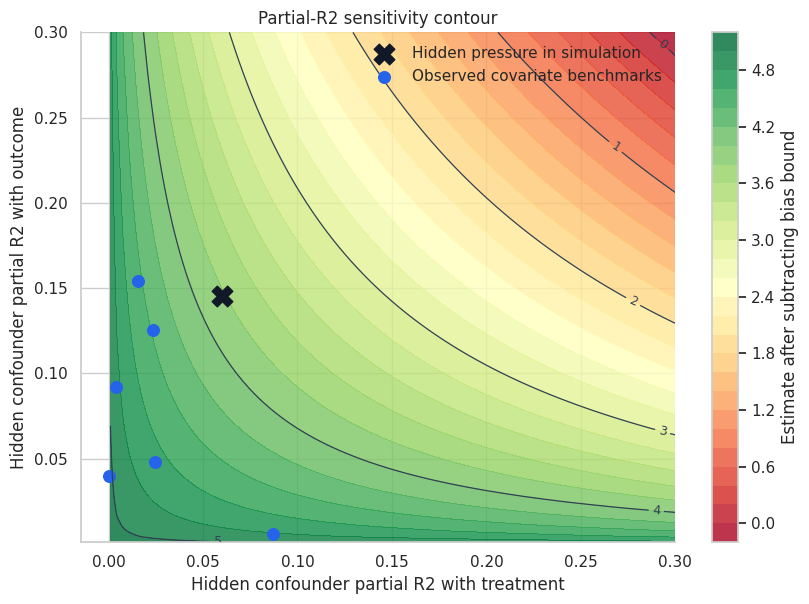

In [10]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
r2_grid = np.linspace(0.001, 0.30, 90)
contour_rows = []
for r2_treatment in r2_grid:
    for r2_outcome in r2_grid:
        bias = omitted_variable_bias_bound(
            analyst_estimate,
            analyst_se,
            analyst_df,
            r2_treatment,
            r2_outcome,
        )
        contour_rows.append({
            "partial_r2_with_treatment": r2_treatment,
            "partial_r2_with_outcome": r2_outcome,
            "bias_bound": bias,
            "lower_adjusted_estimate": analyst_estimate - bias,
        })

contour = pd.DataFrame(contour_rows)
contour_matrix = contour.pivot(index="partial_r2_with_outcome", columns="partial_r2_with_treatment", values="lower_adjusted_estimate")

fig, ax = plt.subplots(figsize=(8.5, 6.2))
levels = [-2, 0, 1, 2, 3, 4, 5, 6]
cs = ax.contour(
    contour_matrix.columns,
    contour_matrix.index,
    contour_matrix.values,
    levels=levels,
    colors="#334155",
    linewidths=0.9,
)
ax.clabel(cs, inline=True, fontsize=9, fmt="%.0f")
filled = ax.contourf(
    contour_matrix.columns,
    contour_matrix.index,
    contour_matrix.values,
    levels=30,
    cmap="RdYlGn",
    alpha=0.82,
)
fig.colorbar(filled, ax=ax, label="Estimate after subtracting bias bound")
ax.scatter(true_u_r2_treatment, true_u_r2_outcome, s=220, marker="X", color="#111827", label="Hidden pressure in simulation")
ax.scatter(benchmark_table["partial_r2_with_treatment"], benchmark_table["partial_r2_with_outcome"], s=70, color="#2563eb", label="Observed covariate benchmarks")
ax.set_title("Partial-R2 sensitivity contour")
ax.set_xlabel("Hidden confounder partial R2 with treatment")
ax.set_ylabel("Hidden confounder partial R2 with outcome")
ax.legend(frameon=False, loc="upper right")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The contour lines show how the conclusion changes as the hidden confounder becomes stronger. A decision threshold can be added to the plot. For example, if outreach must increase renewal value by at least 2 units to be worth the operational cost, then all sensitivity settings below that contour would weaken the business case.

This is often more useful than asking only whether the estimate can be moved exactly to zero.

## 7. A Simple Binary Hidden-Confounder Tipping Grid

Partial-$R^2$ is powerful, but some stakeholders reason more naturally in terms of prevalence and outcome lift.

Suppose a hidden binary confounder is more common among treated accounts than untreated accounts after observed adjustment. Let:

$$
\Delta_U = P(U=1 \mid A=1, X) - P(U=1 \mid A=0, X)
$$

and suppose $U$ increases the outcome by $\gamma$ units after treatment and observed covariates. A simple omitted-confounder bias approximation is:

$$
Bias \approx \gamma \Delta_U.
$$

This transparent tipping-point exercise complements formal design-specific analysis by asking how large the hidden prevalence imbalance and hidden outcome effect would need to be to change the decision.

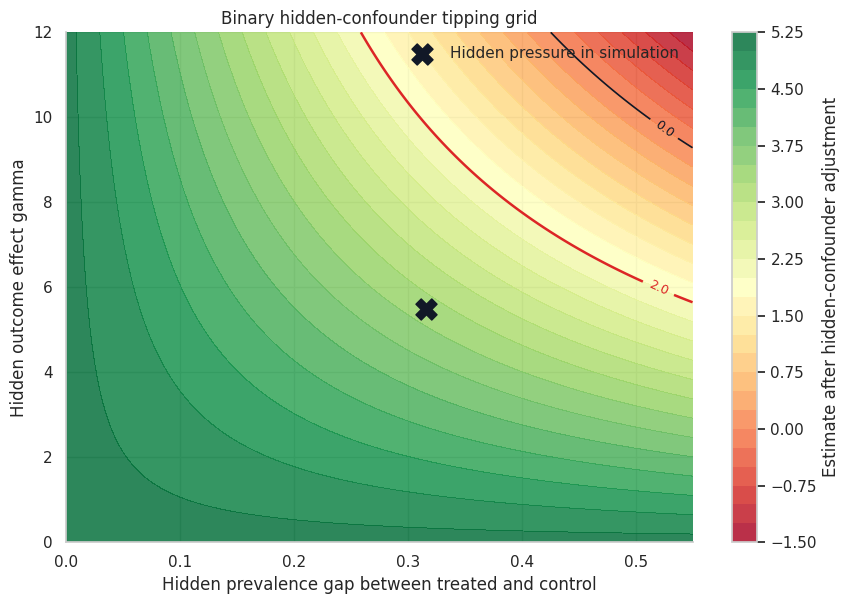

,quantity,value
0,Observed adjusted estimate,5.106
1,Minimum business effect threshold,2.000
2,Actual hidden prevalence gap in simulation,0.316
3,Actual hidden outcome coefficient in oracle model,5.496
4,Actual approximate hidden bias,1.738


In [11]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
gamma_grid = np.linspace(0, 12, 121)
delta_grid = np.linspace(0, 0.55, 111)
minimum_business_effect = 2.0

tipping_rows = []
for gamma in gamma_grid:
    for delta_u in delta_grid:
        bias = gamma * delta_u
        adjusted = analyst_estimate - bias
        tipping_rows.append({
            "hidden_outcome_effect_gamma": gamma,
            "hidden_prevalence_gap_delta": delta_u,
            "bias": bias,
            "adjusted_estimate": adjusted,
            "below_business_threshold": adjusted < minimum_business_effect,
        })

tipping = pd.DataFrame(tipping_rows)
tipping_matrix = tipping.pivot(
    index="hidden_outcome_effect_gamma",
    columns="hidden_prevalence_gap_delta",
    values="adjusted_estimate",
)

actual_prevalence_gap = (
    df.loc[df["treated"] == 1, "executive_pressure"].mean()
    - df.loc[df["treated"] == 0, "executive_pressure"].mean()
)
actual_outcome_association = oracle_model.params["executive_pressure"]

fig, ax = plt.subplots(figsize=(8.8, 6.2))
filled = ax.contourf(
    tipping_matrix.columns,
    tipping_matrix.index,
    tipping_matrix.values,
    levels=30,
    cmap="RdYlGn",
    alpha=0.84,
)
fig.colorbar(filled, ax=ax, label="Estimate after hidden-confounder adjustment")
cs = ax.contour(
    tipping_matrix.columns,
    tipping_matrix.index,
    tipping_matrix.values,
    levels=[0, minimum_business_effect, analyst_estimate],
    colors=["#111827", "#dc2626", "#334155"],
    linewidths=[1.2, 1.8, 1.0],
)
ax.clabel(cs, inline=True, fontsize=9, fmt="%.1f")
ax.scatter(actual_prevalence_gap, actual_outcome_association, s=230, marker="X", color="#111827", label="Hidden pressure in simulation")
ax.set_title("Binary hidden-confounder tipping grid")
ax.set_xlabel("Hidden prevalence gap between treated and control")
ax.set_ylabel("Hidden outcome effect gamma")
ax.legend(frameon=False, loc="upper right")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

binary_tipping_summary = pd.DataFrame({
    "quantity": [
        "Observed adjusted estimate",
        "Minimum business effect threshold",
        "Actual hidden prevalence gap in simulation",
        "Actual hidden outcome coefficient in oracle model",
        "Actual approximate hidden bias",
    ],
    "value": [
        analyst_estimate,
        minimum_business_effect,
        actual_prevalence_gap,
        actual_outcome_association,
        actual_prevalence_gap * actual_outcome_association,
    ],
})

smart_display(binary_tipping_summary)

This plot is often the most useful slide for nontechnical stakeholders. It says: here is the hidden-confounder story required to change the decision.

If leadership believes that hidden escalation pressure could easily be 30 percentage points more common among treated accounts and raise renewal value by 4 to 6 units, then the analysis is fragile. If that story seems implausible, the finding becomes more credible.

## 8. E-Values for a Binary Outcome

The E-value of VanderWeele and Ding (2017) summarizes how strongly an unmeasured confounder would need to be associated with both treatment and outcome, on the risk-ratio scale, to explain away an observed association.

For a risk ratio $RR > 1$, the point-estimate E-value is:

$$
E = RR + \sqrt{RR(RR - 1)}.
$$

The interpretation is: an unmeasured confounder would need to be associated with both treatment and outcome by risk ratios of at least $E$ each, above and beyond the measured covariates, to move the point estimate to the null.

E-values are most natural for ratio-scale effects. Here we use the binary retention outcome and estimate an adjusted risk ratio by outcome-model standardization.

In [12]:
# Fit the statistical model and collect estimates used in the following interpretation.
retention_model = smf.logit(
    f"retained ~ treated + {observed_covariates_formula}",
    data=df,
).fit(disp=False)

d1 = df.copy()
d0 = df.copy()
d1["treated"] = 1
d0["treated"] = 0
p1 = retention_model.predict(d1)
p0 = retention_model.predict(d0)

adjusted_risk_treated = p1.mean()
adjusted_risk_control = p0.mean()
adjusted_rr = adjusted_risk_treated / adjusted_risk_control
adjusted_rd = adjusted_risk_treated - adjusted_risk_control
point_e_value = e_value(adjusted_rr)

# Light bootstrap for an approximate lower confidence bound on the standardized risk ratio.
rng = np.random.default_rng(123)
boot_rr = []
for _ in range(120):
    sample_idx = rng.integers(0, len(df), len(df))
    boot = df.iloc[sample_idx].copy()
    try:
        boot_model = smf.logit(f"retained ~ treated + {observed_covariates_formula}", data=boot).fit(disp=False)
        b1 = boot.copy()
        b0 = boot.copy()
        b1["treated"] = 1
        b0["treated"] = 0
        boot_rr.append(boot_model.predict(b1).mean() / boot_model.predict(b0).mean())
    except Exception:
        continue

rr_ci_low, rr_ci_high = np.quantile(boot_rr, [0.025, 0.975])
ci_e_value = e_value(rr_ci_low if adjusted_rr >= 1 else rr_ci_high)

evalue_table = pd.DataFrame({
    "quantity": [
        "Adjusted retention risk under outreach",
        "Adjusted retention risk under no outreach",
        "Adjusted risk difference",
        "Adjusted risk ratio",
        "Bootstrap RR CI low",
        "Bootstrap RR CI high",
        "Point-estimate E-value",
        "CI-bound E-value closest to null",
    ],
    "value": [
        adjusted_risk_treated,
        adjusted_risk_control,
        adjusted_rd,
        adjusted_rr,
        rr_ci_low,
        rr_ci_high,
        point_e_value,
        ci_e_value,
    ],
})

smart_display(evalue_table)

,quantity,value
0,Adjusted retention risk under outreach,0.690
1,Adjusted retention risk under no outreach,0.613
2,Adjusted risk difference,0.077
3,Adjusted risk ratio,1.126
4,Bootstrap RR CI low,1.074
5,Bootstrap RR CI high,1.162
6,Point-estimate E-value,1.502
7,CI-bound E-value closest to null,1.357


In E-Values for a Binary Outcome, the output makes the remaining uncertainty explicit. The sensitivity question is how strong an omitted explanation would need to be to change the conclusion.

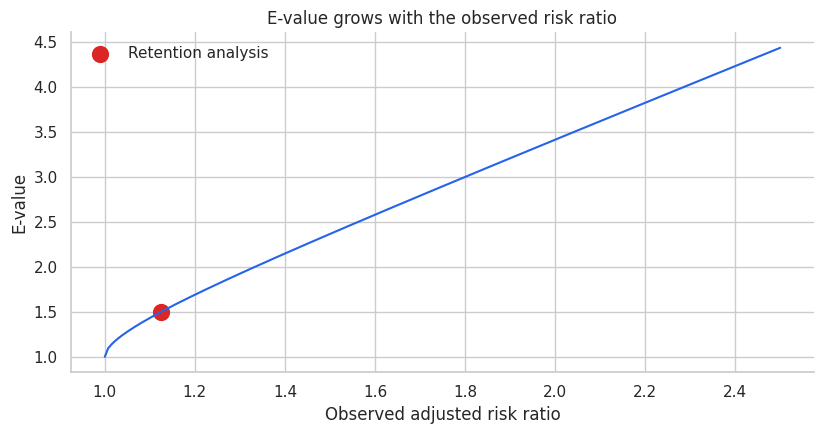

In [13]:
# Build the E-Values for a Binary Outcome plot from the quantities computed above.
rr_grid = np.linspace(1.0, 2.5, 200)
e_values = pd.DataFrame({"risk_ratio": rr_grid, "e_value": [e_value(x) for x in rr_grid]})

fig, ax = plt.subplots(figsize=(8.4, 4.5))
sns.lineplot(data=e_values, x="risk_ratio", y="e_value", ax=ax, color="#2563eb")
ax.scatter(adjusted_rr, point_e_value, s=130, color="#dc2626", label="Retention analysis")
ax.set_title("E-value grows with the observed risk ratio")
ax.set_xlabel("Observed adjusted risk ratio")
ax.set_ylabel("E-value")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The E-value is a compact sensitivity summary. It complements domain reasoning, and VanderWeele and Ding explicitly caution against turning it into an automatic threshold. It is useful for ratio-scale outcomes because it gives stakeholders a single question:

> Would an unmeasured factor with this treatment association and this outcome association be plausible after the covariates we already adjusted for?

## 9. Rosenbaum-Style Hidden Bias for Matched Pairs

For matched observational studies, Rosenbaum's hidden-bias framework asks how much treatment odds could differ within matched pairs because of an unobserved variable.

Let $\Gamma \ge 1$ bound the odds ratio of treatment assignment between two matched units with the same observed covariates. When $\Gamma=1$, treatment assignment is as-if random within pairs. Larger $\Gamma$ allows more hidden bias.

A full Rosenbaum sensitivity analysis can use signed-rank statistics and exact bounds. Here we implement a simple sign-test version for teaching:

1. Match treated accounts to similar control accounts on observed propensity score.
2. Count how often the treated account has a higher outcome than its matched control.
3. Increase $\Gamma$ and compute a conservative upper-bound one-sided p-value.
4. Find the value where the conclusion becomes non-significant.

In [14]:
# Fit the statistical model and collect estimates used in the following interpretation.
ps_match_model = smf.logit(f"treated ~ {observed_covariates_formula}", data=df).fit(disp=False)
match_frame = df.copy()
match_frame["ps_hat"] = ps_match_model.predict(match_frame)

treated_frame = match_frame.loc[match_frame["treated"] == 1].copy()
control_frame = match_frame.loc[match_frame["treated"] == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_frame[["ps_hat"]])
distances, indices = nn.kneighbors(treated_frame[["ps_hat"]])
matched_controls = control_frame.iloc[indices.ravel()].reset_index(drop=True)
matched_treated = treated_frame.reset_index(drop=True)

pairs = matched_treated[["outcome", "ps_hat", "executive_pressure"]].rename(
    columns={"outcome": "treated_outcome", "ps_hat": "treated_ps", "executive_pressure": "treated_hidden_pressure"}
)
pairs["control_outcome"] = matched_controls["outcome"].to_numpy()
pairs["control_ps"] = matched_controls["ps_hat"].to_numpy()
pairs["control_hidden_pressure"] = matched_controls["executive_pressure"].to_numpy()
pairs["outcome_difference"] = pairs["treated_outcome"] - pairs["control_outcome"]
pairs["ps_distance"] = np.abs(pairs["treated_ps"] - pairs["control_ps"])

positive_differences = int((pairs["outcome_difference"] > 0).sum())
nonzero_pairs = int((pairs["outcome_difference"] != 0).sum())
matched_effect = pairs["outcome_difference"].mean()

gamma_grid = np.linspace(1, 2.6, 65)
rosenbaum_rows = []
for gamma in gamma_grid:
    p_upper = gamma / (1 + gamma)
    upper_p_value = binom.sf(positive_differences - 1, nonzero_pairs, p_upper)
    rosenbaum_rows.append({
        "gamma": gamma,
        "upper_bound_p_value": upper_p_value,
        "p_upper": p_upper,
    })

rosenbaum_table = pd.DataFrame(rosenbaum_rows)
critical = rosenbaum_table.loc[rosenbaum_table["upper_bound_p_value"] > 0.05, "gamma"].min()

match_summary = pd.DataFrame({
    "quantity": [
        "Number of matched pairs",
        "Mean treated-control outcome difference",
        "Positive treated-control differences",
        "Median propensity-score distance",
        "Hidden pressure gap in matched pairs",
        "Approximate gamma where p-value exceeds 0.05",
    ],
    "value": [
        len(pairs),
        matched_effect,
        positive_differences,
        pairs["ps_distance"].median(),
        pairs["treated_hidden_pressure"].mean() - pairs["control_hidden_pressure"].mean(),
        critical,
    ],
})

smart_display(match_summary)
smart_display(rosenbaum_table.head())

,quantity,value
0,Number of matched pairs,2.551e+03
1,Mean treated-control outcome difference,5.141e+00
2,Positive treated-control differences,1.666e+03
3,Median propensity-score distance,7.315e-05
4,Hidden pressure gap in matched pairs,2.332e-01
5,Approximate gamma where p-value exceeds 0.05,1.775e+00


,gamma,upper_bound_p_value,p_upper
0,1.000,6.070e-55,0.500
1,1.025,7.921e-51,0.506
2,1.050,5.663e-47,0.512
3,1.075,2.303e-43,0.518
4,1.100,5.510e-40,0.524


In Rosenbaum-Style Hidden Bias for Matched Pairs, the output is useful only if the comparison has support in the data. Sparse comparison regions make broad causal claims harder to defend.

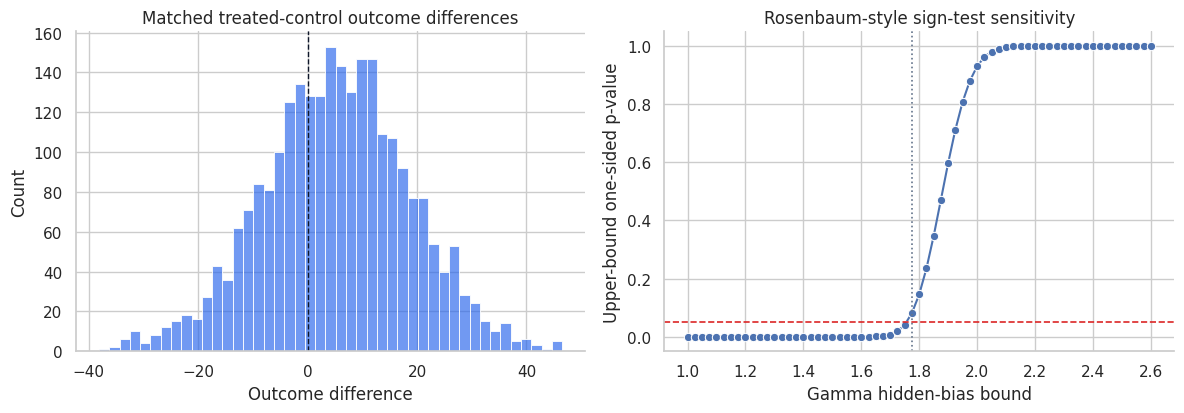

In [15]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

sns.histplot(pairs["outcome_difference"], bins=45, color="#2563eb", alpha=0.65, ax=axes[0])
axes[0].axvline(0, color="#0f172a", linestyle="--", linewidth=1)
axes[0].set_title("Matched treated-control outcome differences")
axes[0].set_xlabel("Outcome difference")

sns.lineplot(data=rosenbaum_table, x="gamma", y="upper_bound_p_value", marker="o", ax=axes[1])
axes[1].axhline(0.05, color="#dc2626", linestyle="--", linewidth=1.2)
if pd.notna(critical):
    axes[1].axvline(critical, color="#64748b", linestyle=":", linewidth=1.2)
axes[1].set_title("Rosenbaum-style sign-test sensitivity")
axes[1].set_xlabel("Gamma hidden-bias bound")
axes[1].set_ylabel("Upper-bound one-sided p-value")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The matched analysis remains significant only up to a certain hidden-bias magnitude. If a modest unobserved factor could increase the odds of outreach within matched pairs by that amount, then the matched conclusion is not very robust.

This sign-test version is deliberately simple. Full Rosenbaum sensitivity analyses can use stronger test statistics, but the interpretation of $\Gamma$ is the key idea.

## 10. Pull the Sensitivity Evidence Together

Sensitivity analysis should end with a synthesis, not a pile of unrelated numbers. The question is whether the observational estimate is stable enough for the decision being made.

In [16]:
# Build the summary table used to connect the calculation back to the design question.
synthesis = pd.DataFrame([
    {
        "lens": "Oracle simulation check",
        "main_quantity": analyst_estimate - oracle_model.params["treated"],
        "plain_language": "Hidden executive pressure would move the observed-adjusted estimate materially if measured.",
    },
    {
        "lens": "Partial-R2 robustness value",
        "main_quantity": rv_null,
        "plain_language": "A hidden confounder with this equal partial-R2 strength on treatment and outcome could move the estimate to zero.",
    },
    {
        "lens": "Benchmarking",
        "main_quantity": benchmark_table["implied_bias_bound_if_hidden"].max(),
        "plain_language": "Observed covariates provide a scale for judging plausible hidden-confounder strength.",
    },
    {
        "lens": "Binary hidden-confounder grid",
        "main_quantity": actual_prevalence_gap * actual_outcome_association,
        "plain_language": "A prevalence-gap times outcome-effect story can be mapped directly to decision thresholds.",
    },
    {
        "lens": "E-value for retention risk ratio",
        "main_quantity": point_e_value,
        "plain_language": "Ratio-scale summary of confounding strength needed to explain away the adjusted retention association.",
    },
    {
        "lens": "Matched-pair hidden-bias gamma",
        "main_quantity": critical,
        "plain_language": "Approximate hidden treatment-odds imbalance within pairs that would make the sign test non-significant.",
    },
])

smart_display(synthesis)

,lens,main_quantity,plain_language
0,Oracle simulation check,1.187,Hidden executive pressure would move the obser...
1,Partial-R2 robustness value,0.293,A hidden confounder with this equal partial-R2...
2,Benchmarking,0.726,Observed covariates provide a scale for judgin...
3,Binary hidden-confounder grid,1.738,A prevalence-gap times outcome-effect story ca...
4,E-value for retention risk ratio,1.502,Ratio-scale summary of confounding strength ne...
5,Matched-pair hidden-bias gamma,1.775,Approximate hidden treatment-odds imbalance wi...


No single sensitivity analysis is definitive. The strength comes from triangulation:

- partial-$R^2$ analysis is useful for linear regression estimates;
- binary tipping grids are useful for stakeholder reasoning;
- E-values are useful for ratio-scale binary outcomes;
- Rosenbaum bounds are useful for matched designs;
- benchmarking keeps all of these anchored to observed domain variables.

The result is not "causal" or "not causal" by formula. The result is a judgment about whether a plausible hidden-confounder story would change the decision.

## 11. What Sensitivity Analysis Cannot Do

Sensitivity analysis is often misunderstood. It cannot:

- discover the missing variable for you;
- prove there is no unmeasured confounding;
- rescue a badly designed observational study;
- replace subject-matter knowledge;
- make post-treatment adjustment valid;
- fix lack of overlap.

It can:

- make the hidden-confounding assumption explicit;
- quantify fragility or robustness;
- help prioritize data collection;
- tell leadership whether an observational estimate is decision-grade or only hypothesis-generating.

## 12. Industry Reporting Template

A useful readout might say:

> The observed-covariate adjusted estimate suggests that proactive outreach increases renewal value by about 5.1 units. Because assignment was not randomized, we assessed sensitivity to unobserved confounding. A hidden confounder with partial-$R^2$ values around the reported robustness threshold on both treatment and outcome could move the estimate to zero. Benchmarking against observed covariates suggests that a hidden factor comparable to executive escalation pressure would materially reduce the estimate. In the matched-pair sensitivity analysis, a hidden factor that changes the odds of outreach within matched pairs by roughly the reported $\Gamma$ value would make the one-sided sign-test result non-significant. We therefore recommend treating the observational estimate as supportive evidence, and we recommend collecting or instrumenting the escalation-pressure variable in future analyses.

That paragraph is much stronger than simply saying "we controlled for many variables." It tells the reader what kind of hidden story would threaten the conclusion.

## Key Takeaways

- Observed balance does not rule out unobserved confounding.
- Sensitivity analysis quantifies how large hidden bias would need to be to change a conclusion.
- Partial-$R^2$ methods are useful for linear regression-style estimates and can be benchmarked against observed covariates.
- Tipping-point grids translate hidden-confounder stories into business language.
- E-values summarize ratio-scale sensitivity for binary outcomes.
- Rosenbaum-style $\Gamma$ analyses are useful for matched observational studies.
- A mature observational study reports sensitivity evidence as part of the main result, not as an appendix afterthought.

## References

Cinelli, C., & Hazlett, C. (2020). Making sense of sensitivity: Extending omitted variable bias. *Journal of the Royal Statistical Society: Series B, 82*(1), 39-67. [https://doi.org/10.1111/rssb.12348](https://doi.org/10.1111/rssb.12348)

Oster, E. (2019). Unobservable selection and coefficient stability: Theory and evidence. *Journal of Business & Economic Statistics, 37*(2), 187-204. [https://doi.org/10.1080/07350015.2016.1227711](https://doi.org/10.1080/07350015.2016.1227711)

Rosenbaum, P. R. (1987). Sensitivity analysis for certain permutation inferences in matched observational studies. *Biometrika, 74*(1), 13-26. [https://doi.org/10.1093/biomet/74.1.13](https://doi.org/10.1093/biomet/74.1.13)

Rosenbaum, P. R., & Rubin, D. B. (1983). Assessing sensitivity to an unobserved binary covariate in an observational study with binary outcome. *Journal of the Royal Statistical Society: Series B, 45*(2), 212-218. [https://doi.org/10.1111/j.2517-6161.1983.tb01242.x](https://doi.org/10.1111/j.2517-6161.1983.tb01242.x)

VanderWeele, T. J., & Ding, P. (2017). Sensitivity analysis in observational research: Introducing the E-value. *Annals of Internal Medicine, 167*(4), 268-274. [https://doi.org/10.7326/M16-2607](https://doi.org/10.7326/M16-2607)